In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 cbir			     README.md
 CBIR.ipynb		     reports
 data			     seg_preparation.ipynb
 global_AE_training.ipynb    subcortical_AE_training.ipynb
 global_SVF_training.ipynb  'subcortical_SVF_training .ipynb'
 model			     training
 preprocessing		     utils


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# import torch
# from model.autoencoder import Conv3DSparseAutoencoder
# from torchsummary import summary

# # Device setup
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Input size: [160, 176, 208]
# input_size = [64, 80, 48]

# # Initialize model and move it to the correct device
# autoencoder = Conv3DSparseAutoencoder().to(device)

# # Run summary — torchsummary will match the device of the model
# _=summary(autoencoder, (1, *input_size))

In [3]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

def plot_deformation_slice(field, dim=0, slice_index=None, step=4, scale=1.0, cmap='viridis'):
    """
    Visualize a 2D slice of a 3D deformation field with a colormap indicating displacement magnitude.

    Parameters:
    - field (np.ndarray): 4D array of shape (160, 176, 208, 3), the deformation field.
    - dim (int): The slicing dimension: 0=axial (x), 1=coronal (y), 2=sagittal (z).
    - slice_index (int): Index of the slice to visualize. If None, uses the center slice.
    - step (int): Sampling step to reduce the number of arrows for clarity.
    - scale (float): Scaling factor for quiver arrows.
    - cmap (str): Matplotlib colormap name for coloring by magnitude.
    """

    assert field.shape[3] == 3, "Last dimension must be 3 (displacement vectors)."

    if slice_index is None:
        slice_index = field.shape[dim] // 2

    if dim == 0:
        # Axial (fix x)
        slice_field = field[slice_index, ::step, ::step, :]
        Y, Z = np.meshgrid(np.arange(0, field.shape[1], step),
                           np.arange(0, field.shape[2], step), indexing='ij')
        U = slice_field[:, :, 1]  # dy
        V = slice_field[:, :, 2]  # dz
        X_plot, Y_plot = Y, Z
        plane = "Axial"
    elif dim == 1:
        # Coronal (fix y)
        slice_field = field[::step, slice_index, ::step, :]
        X, Z = np.meshgrid(np.arange(0, field.shape[0], step),
                           np.arange(0, field.shape[2], step), indexing='ij')
        U = slice_field[:, :, 0]  # dx
        V = slice_field[:, :, 2]  # dz
        X_plot, Y_plot = X, Z
        plane = "Coronal"
    elif dim == 2:
        # Sagittal (fix z)
        slice_field = field[::step, ::step, slice_index, :]
        X, Y = np.meshgrid(np.arange(0, field.shape[0], step),
                           np.arange(0, field.shape[1], step), indexing='ij')
        U = slice_field[:, :, 0]  # dx
        V = slice_field[:, :, 1]  # dy
        X_plot, Y_plot = X, Y
        plane = "Sagittal"
    else:
        raise ValueError("dim must be 0 (axial), 1 (coronal), or 2 (sagittal)")

    # Compute magnitude
    magnitude = np.sqrt(U**2 + V**2)

    # Normalize magnitudes for color mapping
    norm = plt.Normalize(vmin=np.min(magnitude), vmax=np.max(magnitude))
    colors = plt.cm.get_cmap(cmap)(norm(magnitude))

    # Plot
    plt.figure(figsize=(8, 8))
    plt.quiver(X_plot, Y_plot, U, V, magnitude, angles='xy', scale=scale, cmap=cmap)
    plt.xlabel('X' if dim != 0 else 'Y')
    plt.ylabel('Y' if dim == 2 else 'Z')
    plt.title(f"{plane} Slice {slice_index} - Colored by Magnitude")
    plt.colorbar(label='Displacement Magnitude')
    plt.gca().invert_yaxis()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [4]:
# # Loading MRI  paths
# from preprocessing.nii2npy import convert_nii_to_npy
# from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset, get_label

# dataset_path = "/home/maia-user/Dataset/OASIS3/"
# file_paths, file_names = list_files_with_extension(dataset_path, extension="align_norm+cropped.nii.gz")

# raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
# raw_image_ids = np.array([file_path.split('/')[1] for file_path in file_paths])  # e.g., "OAS30001"

# # Optional PE
# # pos_en = positionalencoding2d(4, 128, 128).detach().cpu().numpy()
# pos_en = None

# convert_nii_to_npy(raw_image_paths, raw_image_ids, output_dir="/home/maia-user/Dataset/OASIS3_NPY/", pe=pos_en)

(176, 208, 160) 1.0 0.0


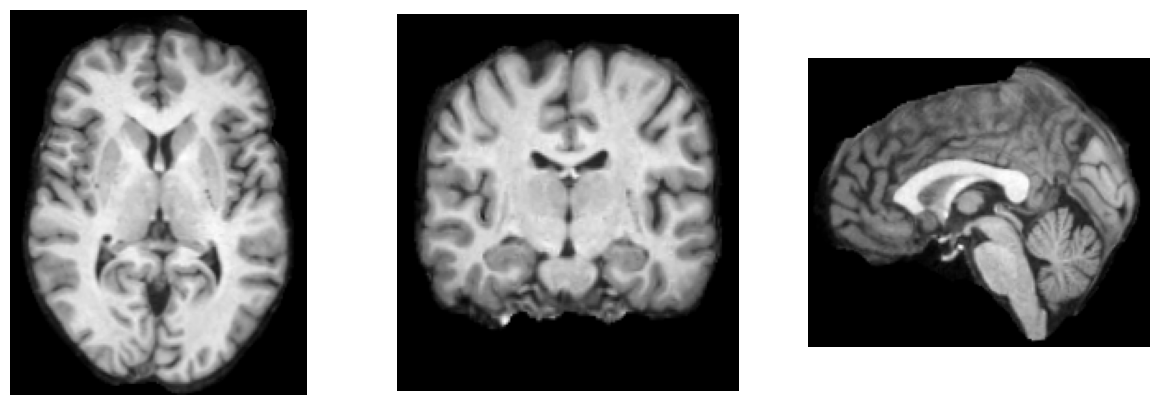

(192, 224, 160) 255 0


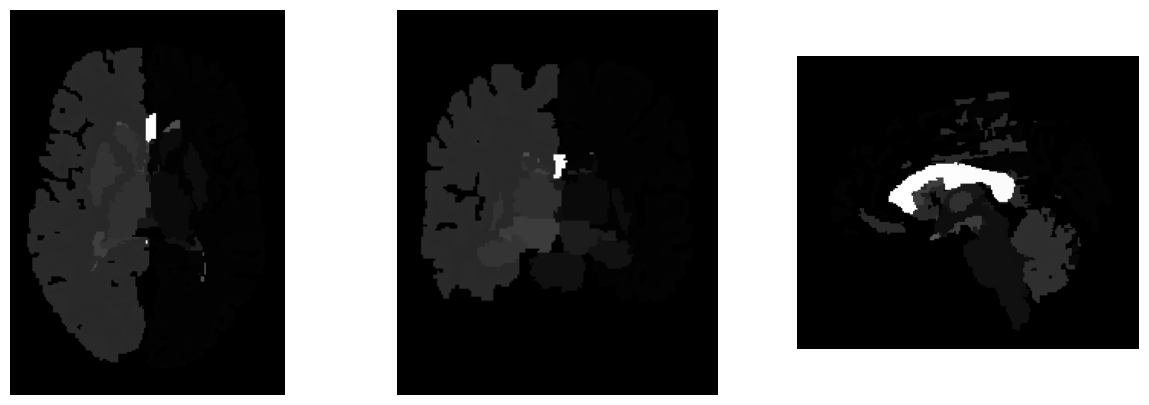

In [5]:
from preprocessing.padding import pad_mri_to_shape

# Load NIfTI file
img_seg = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_UINT/OAS30001_MR_d0129.npy", allow_pickle=True).item()
mri_data = img_seg['image']
mri_data = mri_data.astype(np.float32) / 255.0
seg = img_seg['seg']

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Show a single slice (assuming 3D MRI data)
seg = pad_mri_to_shape(seg, target_shape=(96*2, 112*2, 80*2))
print(seg.shape, np.max(seg), np.min(seg))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(seg[seg.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(seg[:, seg.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(seg[:, :, seg.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()



(96, 112, 80, 3) 5.027 -7.293


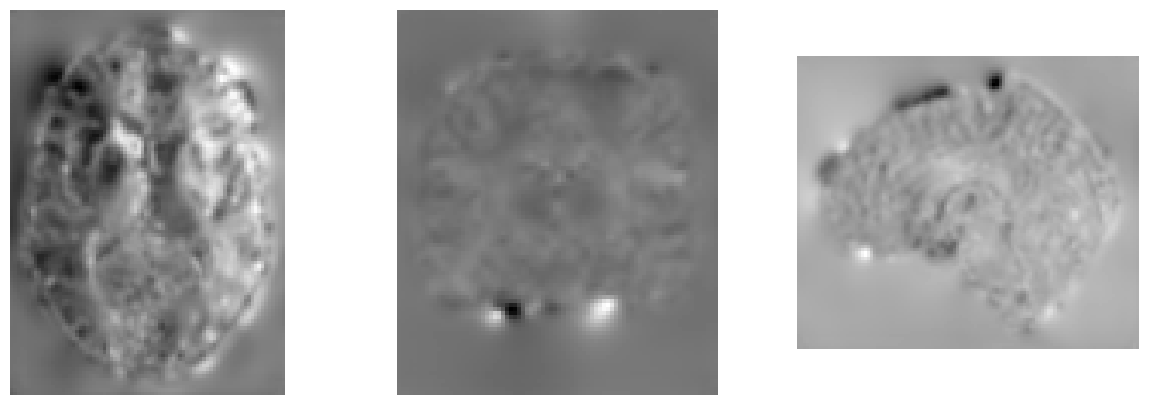

In [6]:
# Load NIfTI file
svf = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_SVF/FROM__OAS30001_MR_d0129__TO__OAS30001_MR_d0757.npy")

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(svf.shape, np.max(svf), np.min(svf))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(svf[svf.shape[0] // 2, : ,:, 0], cmap="gray")
axes[0].axis("off")
axes[1].imshow(svf[:, svf.shape[1] // 2, :, 1], cmap="gray")
axes[1].axis("off")
axes[2].imshow(svf[:, :, svf.shape[2] // 2, 2], cmap="gray")
axes[2].axis("off")
plt.show()

In [7]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_SVF/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')


In [9]:

# Some recordings might be removed, i.e. nan labels
# Match svf and labels
raw_labels = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['disease_label'].max()
                                for image_id in raw_image_ids]).astype('float32')

# Match svf and age dif
raw_ages_dif = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['age_at_visit']
                                for image_id in raw_image_ids]).astype('float32')
raw_ages_dif = raw_ages_dif[:, 1] - raw_ages_dif[:, 0]

# Match svf and id
raw_ids = np.array([labels_df[labels_df['OASISID'].apply(lambda x: pd.notna(x) and x in image_id)]['OASISID'].unique()
                                for image_id in raw_image_ids])

In [10]:
# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages_dif = raw_ages_dif[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)
print(labels.shape, image_paths.shape, ages_dif.shape, ids.shape)

(2778,) (2778,)
(2778,) (2778,) (2778,) (2778, 1)


In [11]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages_dif=ages_dif, ids=ids)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(val_set['image_paths']):.2f}")

Training samples: 1931 - IR: 0.16
Validation samples: 345 - IR: 0.17
Testing samples: 502 - IR: 0.15


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
from preprocessing.load_dataset import StratifiedBatchSampler, BrainSVFDataset
import torchio as tio

batch_size = 4  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])



# Preparing the dataset to feed the network
train_dataset = BrainSVFDataset(train_set['image_paths'], train_set['ages_dif'], train_set['labels'])
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = BrainSVFDataset(val_set['image_paths'], val_set['ages_dif'], val_set['labels'])
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = BrainSVFDataset(test_set['image_paths'], test_set['ages_dif'], test_set['labels'])
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)


torch.Size([1, 3, 112, 80, 96])


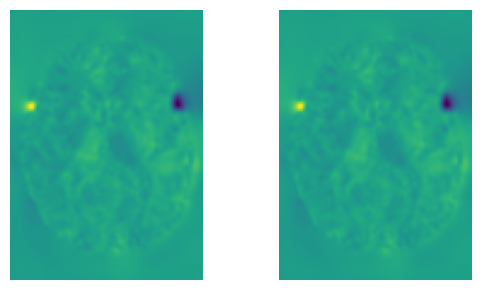

In [14]:
# Fetch one sample from the dataset
sample_1, sample_2 = train_dataset[0], train_dataset[-55]  # Get the first case

# Extract MRI image and mask
svf_1 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension
svf_2 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension
print(sample_1['svf'].shape)

if len(svf_1.shape) > 3:
    subc_st_ind = -3
    svf_1 = svf_1[subc_st_ind]
    svf_2 = svf_2[subc_st_ind]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Load the image
axes[0].imshow(svf_1[:, :,  svf_1.shape[-1] // 2])
axes[0].axis('off')

axes[1].imshow(svf_2[:, :, svf_2.shape[-1] // 2])
axes[1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
# Display the plotS
plt.show()

In [15]:
import torch
from model.autoencoder import Conv3DAutoencoder
from torchsummary import summary

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Input size: [160, 176, 208]
input_size = list(svf_1.shape)

# Initialize model and move it to the correct device
bottleneck_dim=128
autoencoder = Conv3DAutoencoder(bottleneck_dim=bottleneck_dim, output_channels=3).to(device)
# pretrained_param = torch.load('./data/pretrained_models/CP_20250503_083258.pth')
# autoencoder.load_state_dict(pretrained_param)

# Keep only matching keys (ignore fully connected layers)
# pretrained_dict = pretrained_param
# new_model_dict = autoencoder.state_dict()
# pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in new_model_dict}
# # Load weights into the new model
# new_model_dict.update(pretrained_dict)
# autoencoder.load_state_dict(new_model_dict)

# Run summary — torchsummary will match the device of the model
_=summary(autoencoder, (1, *input_size))


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 8, 7, 5, 6]          --
|    └─Sequential: 2-1                   [-1, 32, 56, 40, 48]      --
|    |    └─Conv3d: 3-1                  [-1, 32, 56, 40, 48]      2,080
|    |    └─GroupNorm: 3-2               [-1, 32, 56, 40, 48]      64
|    |    └─ReLU: 3-3                    [-1, 32, 56, 40, 48]      --
|    |    └─Dropout3d: 3-4               [-1, 32, 56, 40, 48]      --
|    └─Sequential: 2-2                   [-1, 24, 28, 20, 24]      --
|    |    └─Conv3d: 3-5                  [-1, 24, 28, 20, 24]      49,176
|    |    └─GroupNorm: 3-6               [-1, 24, 28, 20, 24]      48
|    |    └─ReLU: 3-7                    [-1, 24, 28, 20, 24]      --
|    |    └─Dropout3d: 3-8               [-1, 24, 28, 20, 24]      --
|    └─Sequential: 2-3                   [-1, 16, 14, 10, 12]      --
|    |    └─Conv3d: 3-9                  [-1, 16, 14, 10, 12]      24,592
|   

In [16]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lr = 1e-3
epochs = 50000

decay, no_decay = [], []
for name, param in autoencoder.named_parameters():
    if param.requires_grad:
        if name.endswith("bias") or "bn" in name.lower():
            no_decay.append(param)
        else:
            decay.append(param)

weight_decay = 1e-5
optimizer = torch.optim.AdamW([
    {'params': decay, 'weight_decay': weight_decay},
    {'params': no_decay, 'weight_decay': 0.0}
], lr=lr)

# --- Scheduler ---
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=5e-5, verbose=True
)

criterion = nn.MSELoss()

/home/maia-user/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
from training.report_writer import TrainingReport
from training.train_SVF import train

# Initialize report
report = TrainingReport(autoencoder,
                        input_shape=input_size, 
                        dataset_info={"N_train": len(train_dataset), 
                                      "IR_train": np.sum(train_set['labels'])/len(train_set['image_paths']),
                                      "N_val": len(val_dataset), 
                                      "IR_val": np.sum(val_set['labels'])/len(val_set['image_paths']),
                                      "N_test": len(test_dataset), 
                                      "IR_test": np.sum(test_set['labels'])/len(test_set['image_paths']),
                                      "batch_size": batch_size}, 
                        optimizer=optimizer, 
                        lr=lr, 
                        weight_decay=weight_decay, 
                        scheduler=scheduler,
                        report_dir="reports/logs"
)

train_losses, val_losses = train_SVF(autoencoder, train_loader, val_loader, optimizer, criterion, device, max_epochs=5000, patience=20, es_warmup=150, scheduler=scheduler, report=report)

ImportError: cannot import name 'train_SVF' from 'training.train_T1w' (/home/maia-user/NeuroCBIR/training/train_T1w.py)

In [ ]:
a=1
a

1

1

In [ ]:
dataset = BrainMRIDataset(image_paths, ages, labels,
                          transform=None, transform_age=3, cache=False, sparse_path=False)

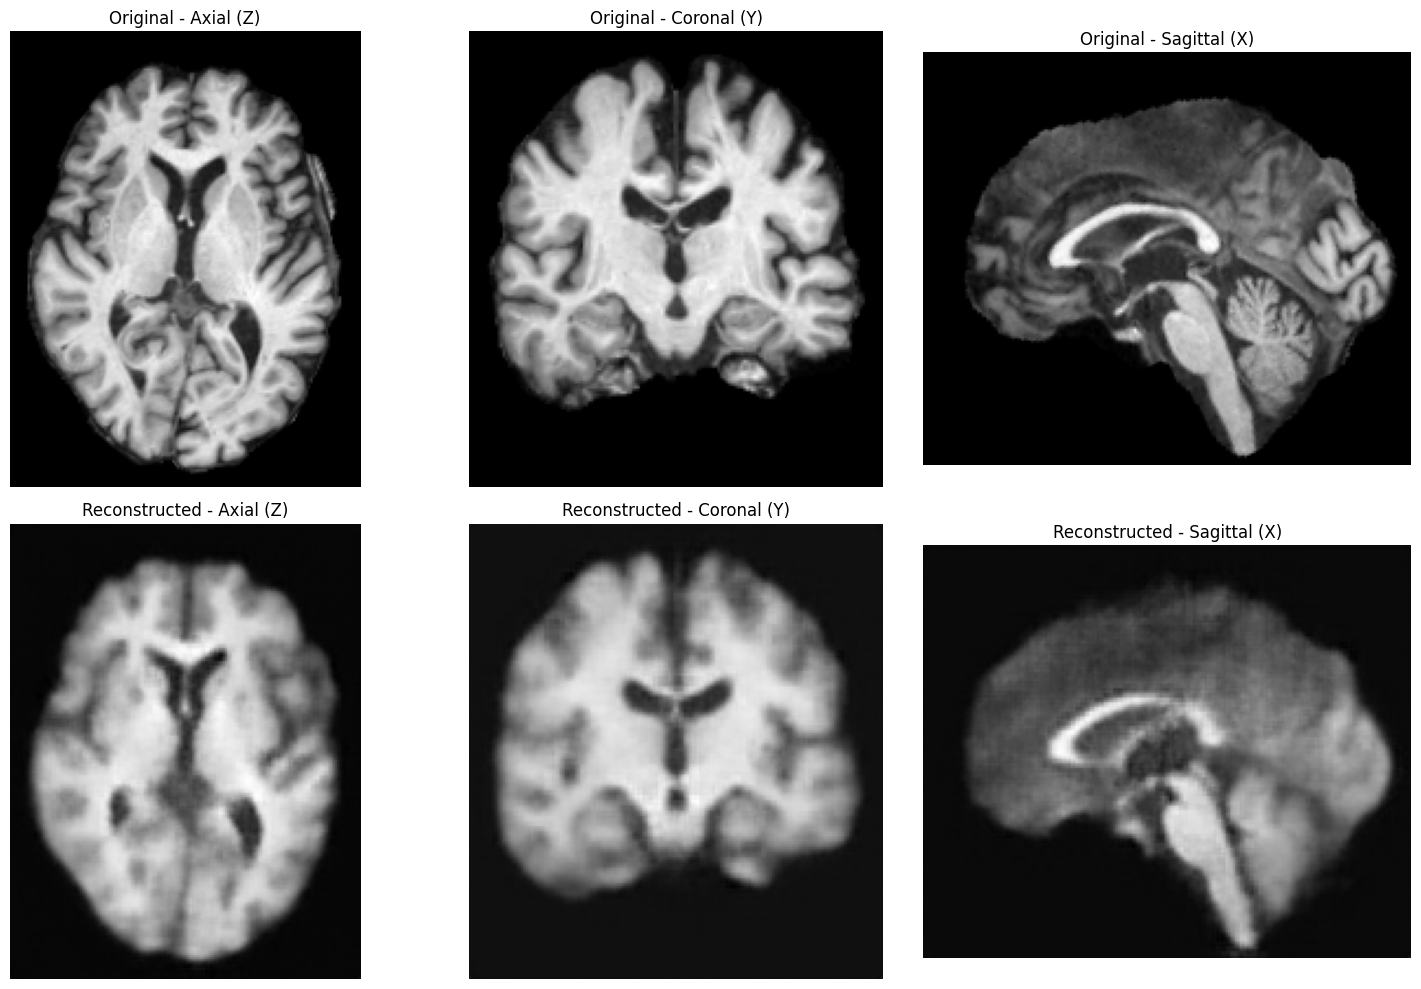

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sample_1 = dataset[178]  # Any sample

autoencoder.eval()

with torch.no_grad():
    subc_struc_ind = 0
    input_img = sample_1["input"].unsqueeze(0).to(device, dtype=torch.float32)
    z, reconstructed = autoencoder(input_img)

# Convert to NumPy
original_np = input_img.squeeze().cpu().numpy()
reconstructed_np = reconstructed.squeeze().cpu().numpy()

# Compute mid-slices
pz = original_np.shape[0] // 2  # Axial
py = original_np.shape[1] // 2  # Coronal
px = original_np.shape[2] // 2  # Sagittal

# Extract slices
slices = {
    "Axial (Z)":      (original_np[pz, :, :], reconstructed_np[pz, :, :]),
    "Coronal (Y)":    (original_np[:, py, :], reconstructed_np[:, py, :]),
    "Sagittal (X)":   (original_np[:, :, px], reconstructed_np[:, :, px]),
}

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (title, (orig, recon)) in enumerate(slices.items()):
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'Original - {title}')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].set_title(f'Reconstructed - {title}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
halt

NameError: name 'halt' is not defined

In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def extract_whole_image_features(autoencoder, dataset, device="cuda", subject_ids=None, record_ids=None, dementia_subcortical_indices=None):
    if not dementia_subcortical_indices:
        dementia_subcortical_indices = {
                    "Hippocampus (lh)": 17, "Hippocampus (rh)": 53, "Amygdala (lh)": 18, "Amygdala (rh)": 54, "Thalamus (lh)": 10,
                    "Thalamus (rh)": 49, "Caudate (lh)": 11, "Caudate (rh)": 50, "Putamen (lh)": 12, "Putamen (rh)": 51,
                }

    autoencoder.to(device)
    autoencoder.eval()
    data = []

    for idx in tqdm(range(len(dataset)), desc="Extracting features"):
        # for ss_idx, (key, _) in enumerate(dementia_subcortical_indices.items()):
        key="whole_brain"
        if record_ids is not None:
            record_id = record_ids[idx]

        if subject_ids is not None:
            subject_id = subject_ids[idx]
            
        sample = dataset[idx]
        img = sample["input"].unsqueeze(0).to(device, dtype=torch.float32)
        
        with torch.no_grad():
            z, _ = autoencoder(img)
        
        data.append({
            "subject_id": subject_id,
            "record_id": record_id,
            "subc_str": key,
            "label": sample["label"].item(),
            "age": sample["age"].item(),
            "features": z.view(-1).cpu().numpy(),
        })
        
    return data

record_ids = [im_path.split("/")[-1].split(".")[0] for im_path in image_paths]

t = -1
dataset = BrainMRIDataset(image_paths[0:t], ages[0:t], labels[0:t],
                          transform=None, transform_age=None, cache=False, sparse_path=None)
dataset_feats = extract_whole_image_features(autoencoder, dataset, device="cpu", record_ids=record_ids[0:t], subject_ids=ids[0:t])

np.save(f"./data/dataset_feats_{report.timestamp}.npy", dataset_feats)

Extracting features:   0%|          | 0/2679 [00:00<?, ?it/s]

Extracting features: 100%|██████████| 2679/2679 [16:56<00:00,  2.63it/s]


In [ ]:
# np.save("./data/dataset_feats.npy", dataset_feats)

In [ ]:
pd.DataFrame(dataset_feats)

,subject_id,record_id,subc_str,label,age,features
0,OAS30647,OAS30647_MR_d0232,Hippocampus (lh),0.0,55.165615,"[3.0249555, -3.566051, -1.4843479, 1.5621015, ..."
1,OAS30647,OAS30647_MR_d0232,Hippocampus (rh),0.0,55.165615,"[-2.0236418, -4.8120666, -0.34693757, -1.34476..."
2,OAS30647,OAS30647_MR_d0232,Amygdala (lh),0.0,55.165615,"[-0.88457066, 0.13977386, -0.93993413, -1.3824..."
3,OAS30647,OAS30647_MR_d0232,Amygdala (rh),0.0,55.165615,"[1.8361444, 2.3839726, -2.6833372, 1.0424763, ..."
4,OAS30647,OAS30647_MR_d0232,Thalamus (lh),0.0,55.165615,"[-0.1933884, -1.0193717, 0.6264281, -0.7820382..."
...,...,...,...,...,...,...
495,OAS30249,OAS30249_MR_d1238,Thalamus (rh),0.0,54.211781,"[-1.9894514, 0.59194374, 1.8113632, 1.6918331,..."
496,OAS30249,OAS30249_MR_d1238,Caudate (lh),0.0,54.211781,"[1.3172529, -0.9376943, -1.2662104, 0.7693468,..."
497,OAS30249,OAS30249_MR_d1238,Caudate (rh),0.0,54.211781,"[-2.390715, -0.15084909, -4.908086, -1.176034,..."
498,OAS30249,OAS30249_MR_d1238,Putamen (lh),0.0,54.211781,"[1.1038939, -0.15658961, -0.6749717, -2.487439..."


In [ ]:
import gc

process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")
gc.collect()
torch.cuda.empty_cache()
process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")

RAM used: 4235.94 MB
RAM used: 4235.94 MB


In [ ]:
record_ids

['OAS30647_MR_d0232',
 'OAS31405_MR_d0149',
 'OAS30901_MR_d0155',
 'OAS30534_MR_d3728',
 'OAS30120_MR_d0784',
 'OAS30947_MR_d1688',
 'OAS30750_MR_d0894',
 'OAS30263_MR_d2483',
 'OAS31415_MR_d0070',
 'OAS30929_MR_d0115',
 'OAS31014_MR_d2235',
 'OAS30219_MR_d1184',
 'OAS30060_MR_d0074',
 'OAS30408_MR_d1193',
 'OAS30590_MR_d0095',
 'OAS30996_MR_d5818',
 'OAS30632_MR_d0106',
 'OAS31114_MR_d4375',
 'OAS31446_MR_d0070',
 'OAS31462_MR_d0107',
 'OAS30754_MR_d0019',
 'OAS30908_MR_d0617',
 'OAS30514_MR_d1526',
 'OAS30908_MR_d0065',
 'OAS30808_MR_d0498',
 'OAS30178_MR_d1384',
 'OAS30182_MR_d1397',
 'OAS31014_MR_d3555',
 'OAS30848_MR_d0070',
 'OAS31440_MR_d0040',
 'OAS30443_MR_d2432',
 'OAS31005_MR_d0066',
 'OAS30532_MR_d0047',
 'OAS30185_MR_d6000',
 'OAS30732_MR_d0074',
 'OAS30376_MR_d0082',
 'OAS30729_MR_d4384',
 'OAS30909_MR_d0109',
 'OAS30048_MR_d2292',
 'OAS30119_MR_d3722',
 'OAS30731_MR_d3375',
 'OAS31338_MR_d0120',
 'OAS30869_MR_d0077',
 'OAS30726_MR_d0061',
 'OAS30502_MR_d0395',
 'OAS30445